In [23]:
from spin_lattices import SpinLattice, KagomeLattice, SquareLattice, TriangularLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
import numpy as np
import numpy.typing as npt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from misc_utils import hadamard_transform_pytorch_inplace
import torch
import unittest
from tqdm.auto import tqdm
from fourier_supervised_cleanroom_2023_09_27 import get_config, output_dir, default_config
from misc_utils import read_jsonl_to_df, keep_serializable, column_to
from nn_supervised_reproduction import output_dir as nn_output_dir, default_config as nn_default_config
from scipy.special import comb

In [24]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
    .rename(columns={"overlap": "test_overlap", "accuracy": "test_accuracy"})
)
# df_nn = read_jsonl_to_df(nn_output_dir.glob("*/results.jsonl")).fillna(
#     keep_serializable(nn_default_config)
# )
# df_full = pd.concat([df.assign(method="Fourier"), df_nn.assign(method="NN")], axis=0).fillna(
#     {"current_timestamp": "unknown", "start_timestamp": "unknown"}
# )

In [25]:
df.query("task_id == 0")['J2'].unique()[-1]

1.0

In [31]:
df.query("task_id == 0 and J2 == 1 and keep_terms == 2 and eps_train == 0.01")

,n_test,sampling_power_train,lattice,keep_terms,test_accuracy,test_overlap,weight_kept,eps_train,J2,n_spins,task_id,J2s,accuracy_reconstructed_vs_previous,accuracy_predicted_vs_previous,overlap_predicted_vs_previous
13924,50000,2.0,kagome2x4,2,0.50250,0.087303,0.000074,0.01,1.0,24,0,NaN,NaN,NaN,NaN
14936,50000,2.0,kagome2x4,2,0.50508,0.085843,0.000073,0.01,1.0,24,0,NaN,NaN,NaN,NaN


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


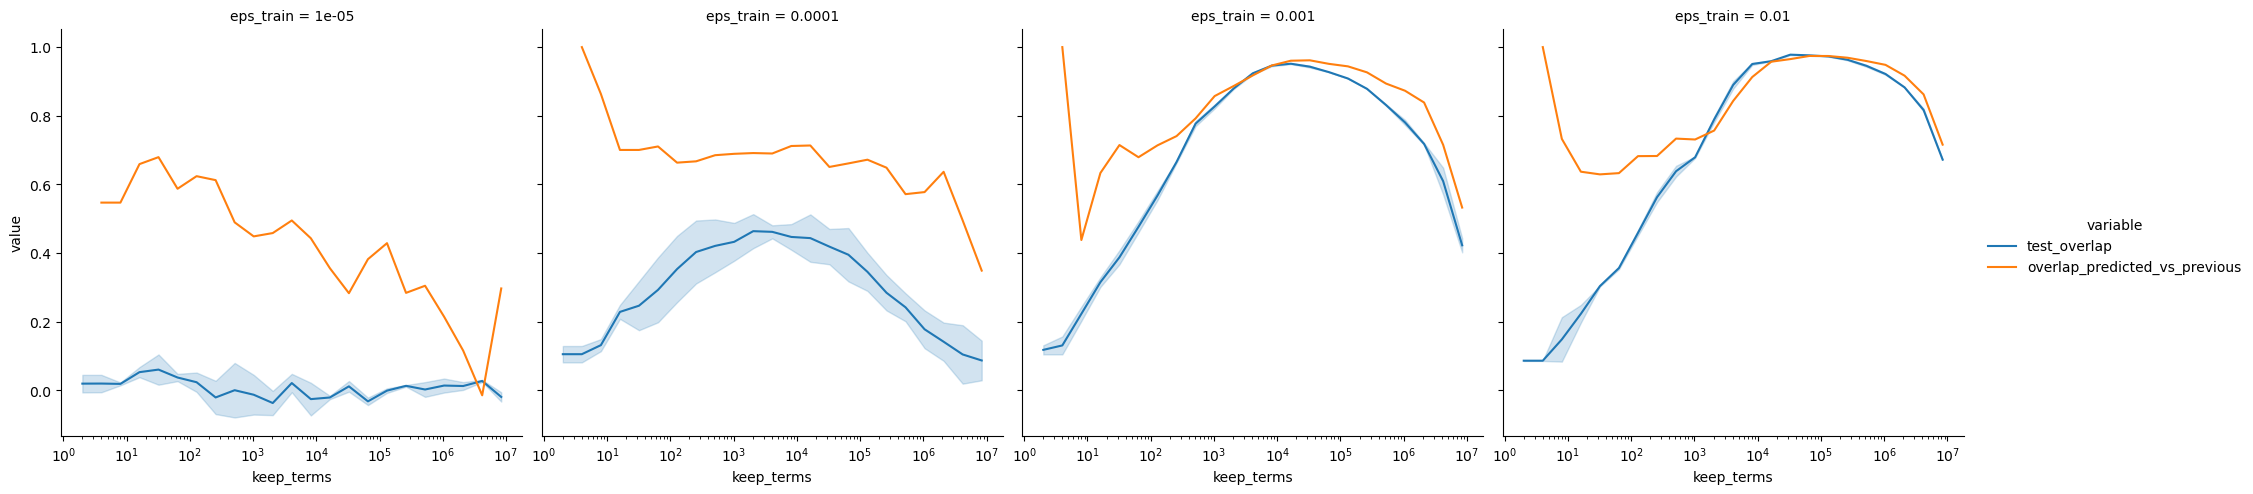

In [27]:
sns.relplot(
    df.query("task_id == 0 and J2 == 1").melt(
        id_vars=["sampling_power_train", "lattice", "keep_terms", "J2", "eps_train"],
        value_vars=["test_overlap", "overlap_predicted_vs_previous"],
    ),
    x="keep_terms",
    y="value",
    hue="variable",
    col='eps_train',
    kind='line',
).set(xscale='log')

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


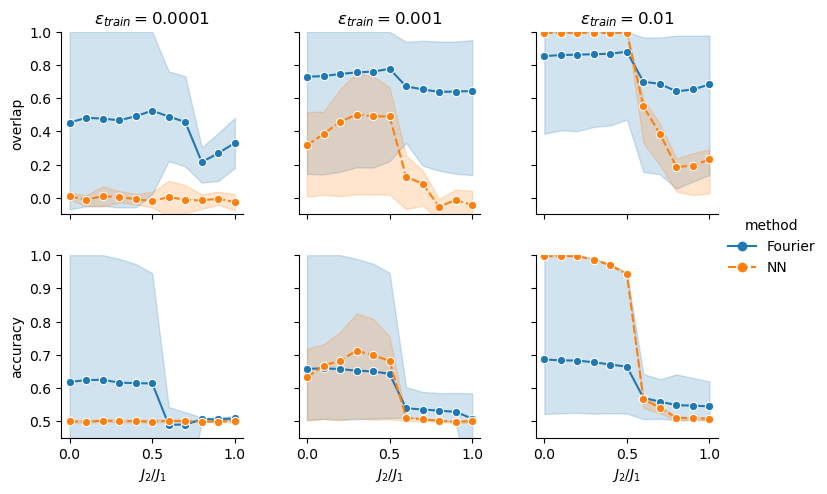

In [64]:
g = sns.relplot(
    df_full.query('lattice == "kagome2x4"' "and sampling_power_train == 2 ")
    .rename(
        columns={
            "J2": "$J_2/J_1$",
            "eps_train": r"$\varepsilon_{train}$",
            "test_overlap": "overlap",
            "test_accuracy": "accuracy",
        }
    )
    .melt(
        id_vars=["method", "$J_2/J_1$", r"$\varepsilon_{train}$", "start_timestamp"],
        value_vars=["overlap", "accuracy"],
        var_name="metric",
        value_name="score",
    ),
    x="$J_2/J_1$",
    y="score",
    kind="line",
    errorbar="pi",
    hue="method",
    row="metric",
    col=r"$\varepsilon_{train}$",
    style="method",
    markers=["o", "o"],
    height=2.5,
    facet_kws={"sharey": False},
)

g.axes[0, 0].set_ylabel('overlap')
g.axes[1, 0].set_ylabel('accuracy')

# Customize column titles
for ax, title in zip(g.axes[0], g.col_names):
    ax.set_title(rf"$\varepsilon_{{train}} = {title}$")

for ax, title in zip(g.axes[1], g.col_names):
    ax.set_title("")

# Update y-limits for each row
for ax in g.axes[0, :]:
    ax.set_ylim(-0.1, 1)
for ax in g.axes[1, :]:
    ax.set_ylim(0.45, 1)

# Remove ticks and labels on each vertical axes except the leftmost ones
for row_axes in g.axes:
    for ax in row_axes[1:]:
        ax.set_ylabel('')
        ax.set_yticklabels([])
# plt.tight_layout()
plt.savefig("fig/fourier_vs_nn.pdf")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


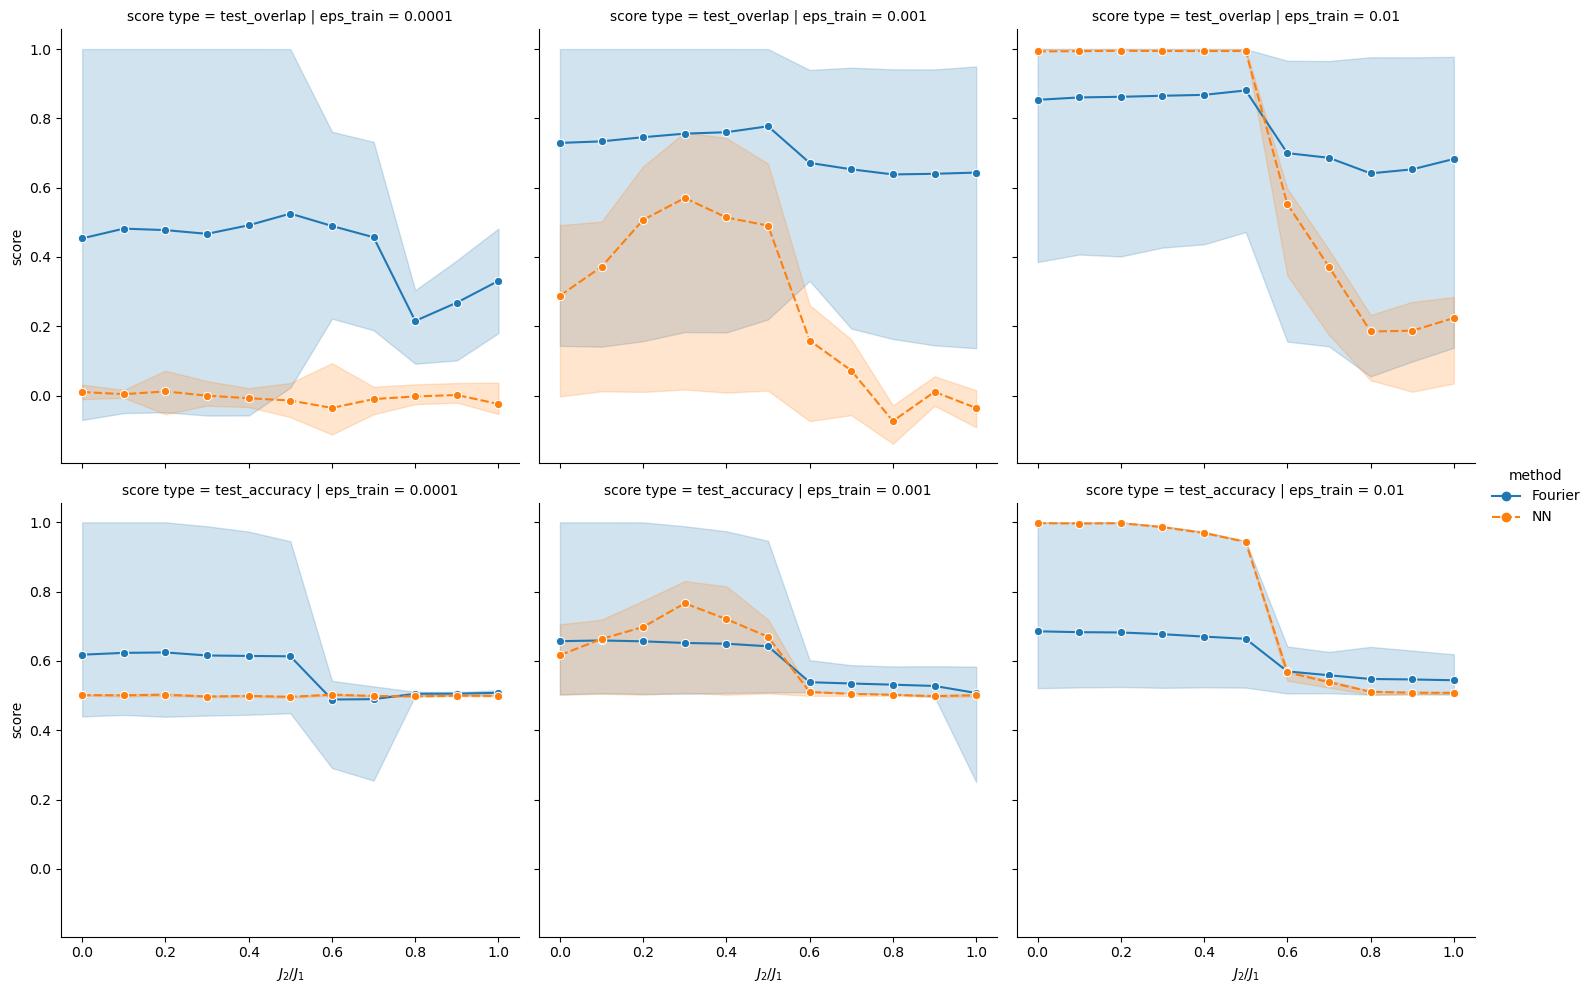

In [20]:
sns.relplot(
    df_full.query('lattice == "kagome2x4"' "and sampling_power_train == 2 ")
    .melt(
        id_vars=["J2", "eps_train", "method", "lattice", "sampling_power_train"],
        value_vars=["test_overlap", "test_accuracy"],
        value_name="score",
        var_name="score type",
    )
    .rename(columns={"J2": "$J_2/J_1$"}),
    x="$J_2/J_1$",
    y="score",
    kind="line",
    errorbar="pi",
    hue="method",
    col="eps_train",
    row='score type',
    style="method",
    markers=["o", "o"],
    #height=2.5,
)
#plt.savefig("fig/fourier_vs_nn.pdf")

In [64]:
df.columns

Index(['n_test', 'lattice', 'keep_terms', 'accuracy', 'test_overlap',
       'weight_kept', 'eps_train', 'J2', 'n_spins', 'task_id',
       'sampling_power_train'],
      dtype='object')

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


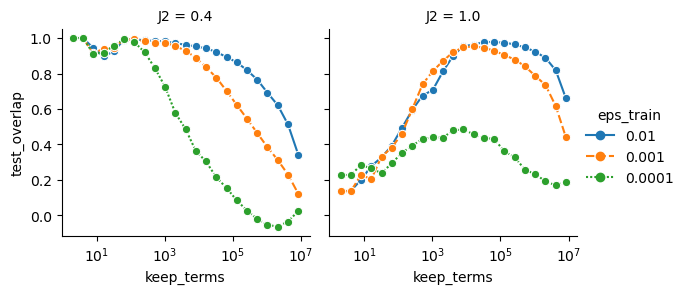

In [75]:
sns.relplot(
    df.query('lattice == "kagome2x4" and sampling_power_train == 2 and J2 in [0.4, 1]').pipe(
        column_to(str, "eps_train")
    ),
    x="keep_terms",
    y="test_overlap",
    hue="eps_train",
    style="eps_train",
    markers=['o', 'o', 'o'],
    kind='line',
    col='J2',
    height=3,
).set(xscale='log')
plt.savefig("fig/fourier_overlap-vs-keep-terms.pdf")

In [5]:
df.query('lattice in ["kagome3x3"] and sampling_power_train == 2 and J2 == 1')

,n_test,sampling_power_train,lattice,keep_terms,test_accuracy,test_overlap,weight_kept,eps_train,J2,n_spins,task_id,J2s
4272,50000,2.0,kagome3x3,2,0.49922,0.047958,0.000016,0.01000,1.0,27,1,NaN
4273,50000,2.0,kagome3x3,4,0.49922,0.047958,0.000032,0.01000,1.0,27,1,NaN
4274,50000,2.0,kagome3x3,8,0.50108,0.062489,0.000062,0.01000,1.0,27,1,NaN
4275,50000,2.0,kagome3x3,16,0.50452,0.080842,0.000120,0.01000,1.0,27,1,NaN
4276,50000,2.0,kagome3x3,32,0.50408,0.132152,0.000232,0.01000,1.0,27,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8652,50000,2.0,kagome3x3,4194304,0.50070,0.034514,0.199130,0.00001,1.0,27,16,[1.0]
8653,50000,2.0,kagome3x3,8388608,0.50278,0.007058,0.323167,0.00001,1.0,27,16,[1.0]
8654,50000,2.0,kagome3x3,16777216,0.50336,0.061641,0.500505,0.00001,1.0,27,16,[1.0]
8655,50000,2.0,kagome3x3,33554432,0.50114,0.048415,0.721693,0.00001,1.0,27,16,[1.0]


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


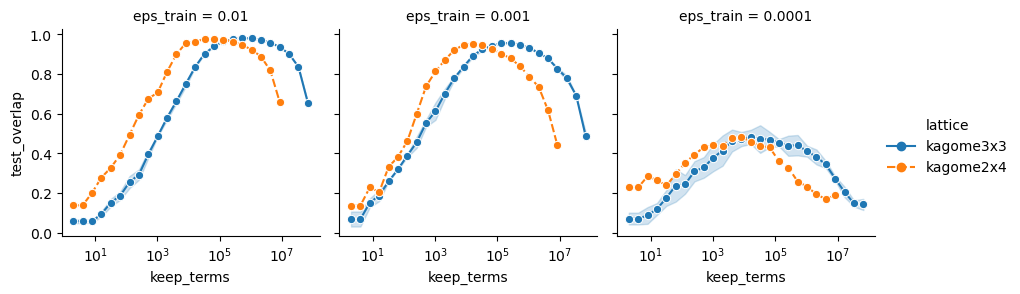

In [6]:
sns.relplot(
    df.query(
        'lattice in ["kagome2x4", "kagome3x3"] and sampling_power_train == 2 and J2 == 1 and eps_train > 1e-5'
    ).pipe(column_to(str, "eps_train")),
    x="keep_terms",
    y="test_overlap",
    col="eps_train",
    hue="lattice",
    style="lattice",
    markers=["o", "o"],
    kind="line",
    height=3,
).set(xscale="log")

In [5]:
# sns.relplot(
#     df.melt(
#         id_vars=["J2", "lattice", "eps_train", "sampling_power_train", "keep_terms"],
#         value_vars=["overlap", "accuracy"],
#     ).query('lattice == "kagome2x4" and eps_train == 0.01'),
#     col="J2",
#     y="value",
#     hue="variable",
#     x="sampling_power_train",
#     kind='line',
#     row='keep_terms',
#     markers=['o'],
#     dashes=False,
#     style="variable",
# )

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


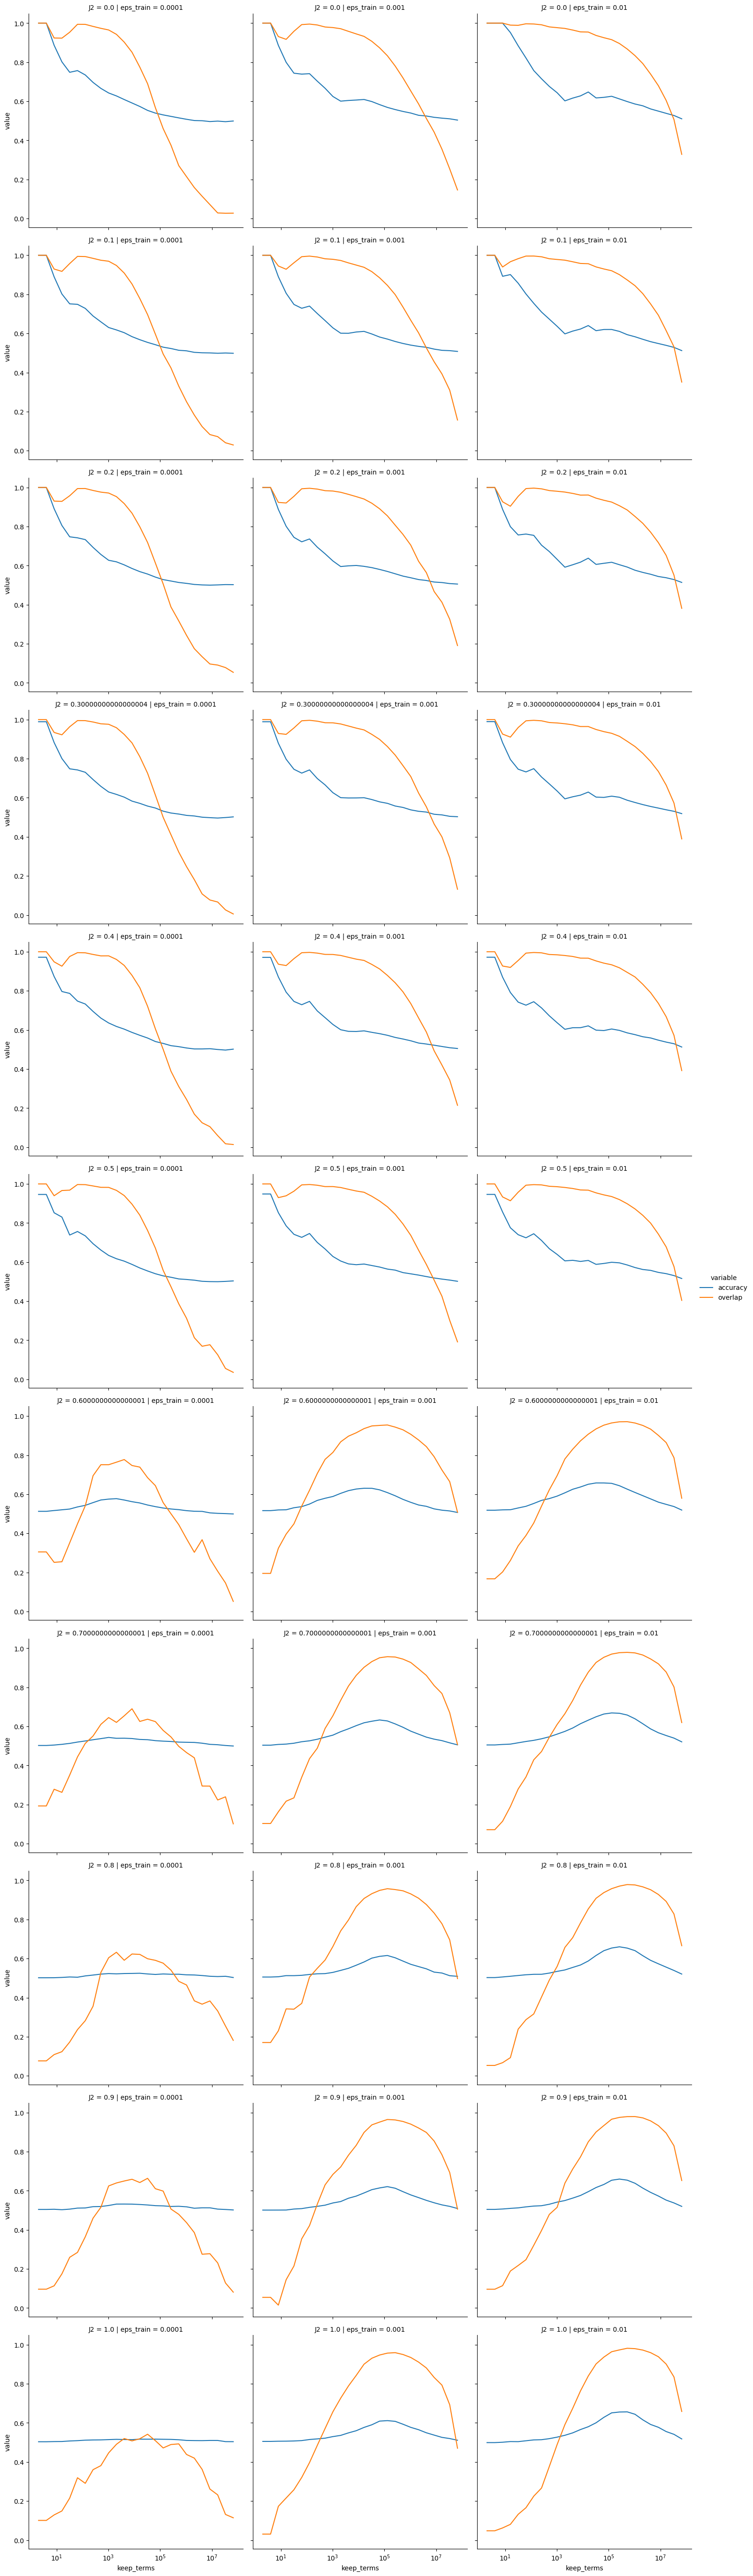

In [5]:
sns.relplot(
    df.query('lattice=="kagome3x3"').melt(
        id_vars=["keep_terms", "eps_train", "weight_kept", "lattice", "J2"],
        value_vars=["accuracy", "overlap", "weight_kept"],
    ),
    x="keep_terms",
    y="value",
    hue="variable",
    col="eps_train",
    row="J2",
    kind="line",
).set(xscale="log")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


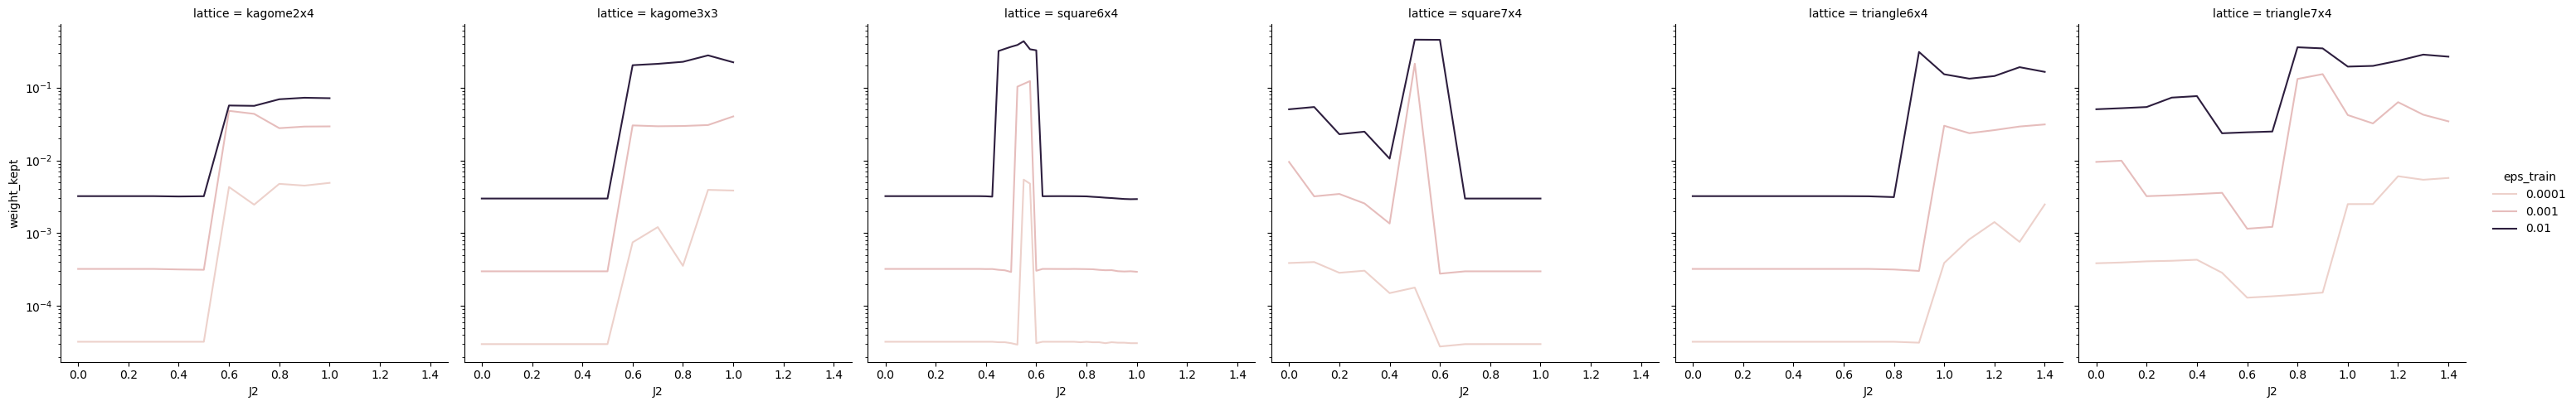

In [4]:
sns.relplot(
    df.loc[df.groupby(['lattice', 'eps_train', 'J2'])['overlap'].idxmax().reset_index(drop=True)],
    x='J2',
    y='weight_kept',
    hue='eps_train',
    col='lattice',
    kind='line',
).set(yscale='log')

/tmp/nix-shell.zW0Zbq/ipykernel_2892212/739468236.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


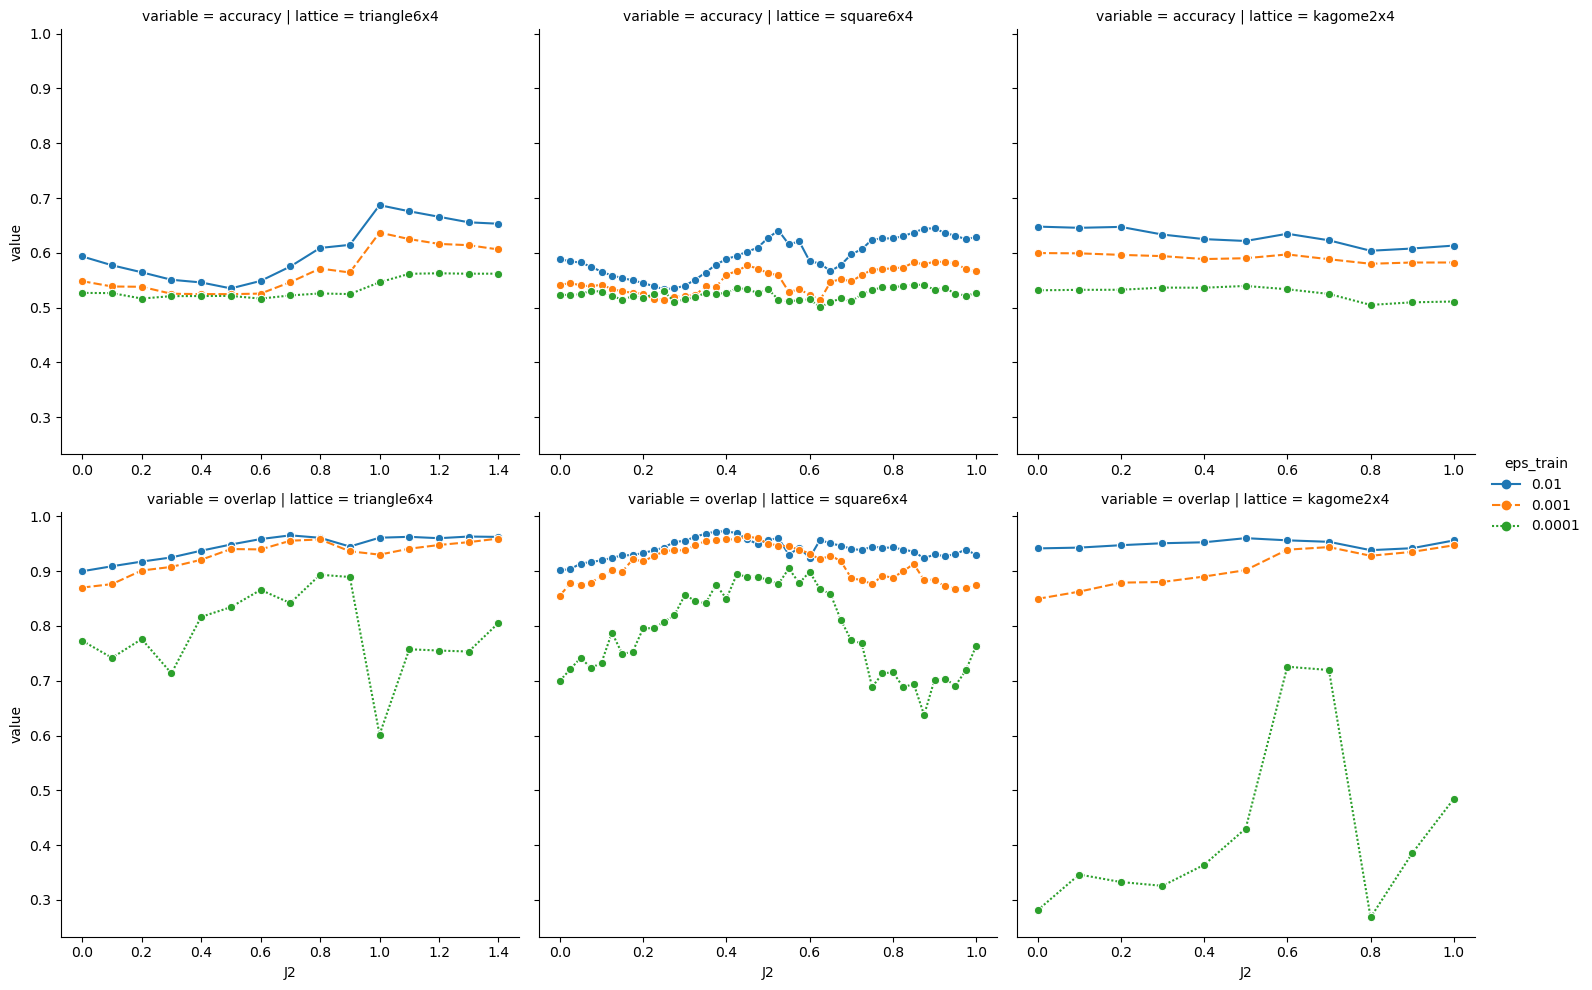

In [16]:
g = sns.relplot(
    df.query("n_spins == 24 and sampling_power_train == 2 and keep_terms == 2 ** 13").melt(
        id_vars=["J2", "lattice", "eps_train", "keep_terms", "sampling_power_train"],
        value_vars=["accuracy", "overlap"],
    ).pipe(column_to(str, "eps_train")),
    x="J2",
    y="value",
    col="lattice",
    hue="eps_train",
    kind="line",
    row="variable",
    style='eps_train',
    markers=['o'],
    facet_kws=dict(sharex=False),
)
g.fig.savefig("fig/fourier_supervised_cleanroom-overlap-accuracy.pdf")

In [25]:
df.assign(log2_keep_terms=np.log2(df["keep_terms"]).astype(int)).query(
        "lattice == 'kagome2x4' and sampling_power_train == 2"
    )['J2'].unique()[3]

0.30000000000000004

In [69]:
(
    df.query('(lattice == "kagome2x4" and J2 == 1)')
    .groupby(["sampling_power_train", "lattice"])[["overlap", "accuracy"]]
    .max()
    .reset_index()
    .melt(id_vars=["sampling_power_train", "lattice"], value_vars=["overlap", "accuracy"])
)

,sampling_power_train,lattice,variable,value
0,0.01,kagome2x4,overlap,0.136493
1,0.50,kagome2x4,overlap,0.959515
2,1.00,kagome2x4,overlap,0.991756
3,2.00,kagome2x4,overlap,0.979280
4,4.00,kagome2x4,overlap,0.955543
5,0.01,kagome2x4,accuracy,0.515420
6,0.50,kagome2x4,accuracy,0.600740
7,1.00,kagome2x4,accuracy,0.644300
8,2.00,kagome2x4,accuracy,0.620040
9,4.00,kagome2x4,accuracy,0.612220


In [32]:
df_full.columns

Index(['n_test', 'sampling_power_train', 'lattice', 'keep_terms',
       'test_accuracy', 'test_overlap', 'weight_kept', 'eps_train', 'J2',
       'n_spins', 'task_id', 'method', 'architecture', 'n_hidden',
       'hidden_layers', 'epochs', 'write_each_epoch', 'lr', 'batch_size',
       'shuffle', 'train_loss', 'epoch', 'start_timestamp',
       'current_timestamp'],
      dtype='object')

In [46]:
(
    df_full.query('(lattice == "kagome2x4" and J2 == 1 and sampling_power_train <= 10)')
    .groupby(["sampling_power_train", "lattice", "eps_train", "method", "start_timestamp"])[
        ["test_overlap", "test_accuracy"]
    ]
    .max()
    .reset_index()
    .melt(
        id_vars=["sampling_power_train", "lattice", "eps_train", "method", "start_timestamp"],
        value_vars=["test_overlap", "test_accuracy"],
        value_name="score",
        var_name="score type",
    )
    .pipe(column_to(str, "eps_train"))
)

,sampling_power_train,lattice,eps_train,method,start_timestamp,score type,score
0,0.01,kagome2x4,0.0001,Fourier,unknown,test_overlap,0.090244
1,0.01,kagome2x4,0.0001,NN,20231012_003105,test_overlap,0.082150
2,0.01,kagome2x4,0.0001,NN,20231012_122758,test_overlap,0.066491
3,0.01,kagome2x4,0.0001,NN,20231013_045237,test_overlap,0.037007
4,0.01,kagome2x4,0.0001,NN,20231013_225053,test_overlap,0.063440
...,...,...,...,...,...,...,...
295,10.00,kagome2x4,0.01,Fourier,unknown,test_accuracy,0.603100
296,10.00,kagome2x4,0.01,NN,20231012_043259,test_accuracy,0.516380
297,10.00,kagome2x4,0.01,NN,20231012_180008,test_accuracy,0.514220
298,10.00,kagome2x4,0.01,NN,20231013_112104,test_accuracy,0.515780


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


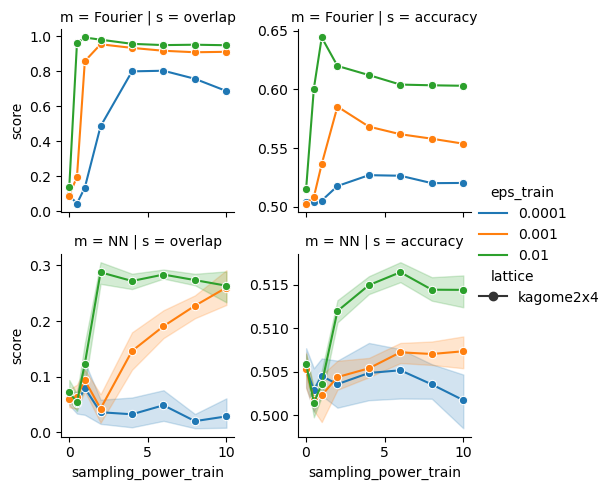

In [53]:
sns.relplot(
    (
        df_full.query('(lattice == "kagome2x4" and J2 == 1 and sampling_power_train <= 10)')
        .rename(columns={"test_overlap": "overlap", "test_accuracy": "accuracy"})
        .groupby(["sampling_power_train", "lattice", "eps_train", "method", "start_timestamp"])[
            ["overlap", "accuracy"]
        ]
        .max()
        .reset_index()
        .melt(
            id_vars=[
                "sampling_power_train",
                "lattice",
                "eps_train",
                "method",
                "start_timestamp",
            ],
            value_vars=["overlap", "accuracy"],
            value_name="score",
            var_name="s",
        )
        .pipe(column_to(str, "eps_train"))
    ).rename(columns={"method": "m"}),
    x="sampling_power_train",
    y="score",
    kind="line",
    markers=["o"],
    col="s",
    row="m",
    hue="eps_train",
    style="lattice",
    height=2.5,
    facet_kws=dict(sharey=False),
)
plt.savefig("fig/fourier_supervised_cleanroom-overlap-vs-sampling_power_train.pdf")

In [20]:
df_nn

,n_test,sampling_power_train,architecture,n_hidden,hidden_layers,epochs,write_each_epoch,lr,batch_size,shuffle,lattice,test_overlap,test_accuracy,train_loss,epoch,J2,eps_train,start_timestamp,current_timestamp
0,50000,8.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.007118,0.50758,0.697993,0,0.0,0.0100,20231012_165745,20231012_165748
1,50000,8.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.175245,0.57884,0.685703,1,0.0,0.0100,20231012_165745,20231012_165750
2,50000,8.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.345455,0.63696,0.636752,2,0.0,0.0100,20231012_165745,20231012_165751
3,50000,8.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.693377,0.78206,0.518849,3,0.0,0.0100,20231012_165745,20231012_165753
4,50000,8.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.850063,0.86368,0.337246,4,0.0,0.0100,20231012_165745,20231012_165754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1518151,50000,6.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,-0.012563,0.49792,0.000538,995,1.0,0.0001,20231014_005017,20231014_070044
1518152,50000,6.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,-0.003169,0.49792,0.000552,996,1.0,0.0001,20231014_005017,20231014_070044
1518153,50000,6.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.006864,0.49804,0.000520,997,1.0,0.0001,20231014_005017,20231014_070044
1518154,50000,6.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,-0.007113,0.49796,0.000549,998,1.0,0.0001,20231014_005017,20231014_070044


In [26]:
(df_nn.query('(lattice == "kagome2x4" and J2 == 1 and sampling_power_train <= 10)')
        .groupby(["sampling_power_train", "lattice", "eps_train", "start_timestamp"])[
            ["test_overlap", "test_accuracy"]
        ]
        .max()
        .reset_index()
        .melt(
            id_vars=["sampling_power_train", "lattice", "eps_train"],
            value_vars=["test_overlap", "test_accuracy"],
            value_name="score",
            var_name="score type",
        ))

,sampling_power_train,lattice,eps_train,score type,score
0,0.01,kagome2x4,0.0001,test_overlap,0.082150
1,0.01,kagome2x4,0.0001,test_overlap,0.066491
2,0.01,kagome2x4,0.0001,test_overlap,0.037007
3,0.01,kagome2x4,0.0001,test_overlap,0.063440
4,0.01,kagome2x4,0.0001,test_overlap,0.070465
...,...,...,...,...,...
211,10.00,kagome2x4,0.0010,test_accuracy,0.508340
212,10.00,kagome2x4,0.0100,test_accuracy,0.516380
213,10.00,kagome2x4,0.0100,test_accuracy,0.514220
214,10.00,kagome2x4,0.0100,test_accuracy,0.515780


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


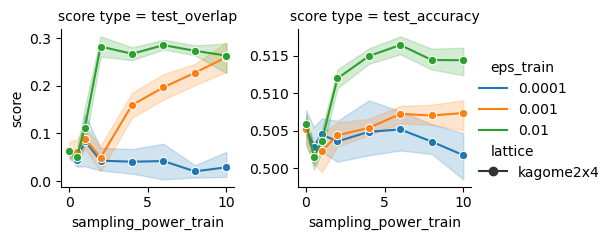

In [28]:
sns.relplot(
    (
        (df_nn.query('(lattice == "kagome2x4" and J2 == 1 and sampling_power_train <= 10)')
        .groupby(["sampling_power_train", "lattice", "eps_train", "start_timestamp"])[
            ["test_overlap", "test_accuracy"]
        ]
        .max()
        .reset_index()
        .melt(
            id_vars=["sampling_power_train", "lattice", "eps_train"],
            value_vars=["test_overlap", "test_accuracy"],
            value_name="score",
            var_name="score type",
        ))
    ).pipe(column_to(str, "eps_train")),
    x="sampling_power_train",
    y="score",
    hue="eps_train",
    col="score type",
    kind="line",
    style="lattice",
    markers=['o'],
    facet_kws=dict(sharey=False),
    height=2.5,
)
# plt.savefig("fig/fourier_supervised_cleanroom-overlap-vs-sampling_power_train.pdf")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


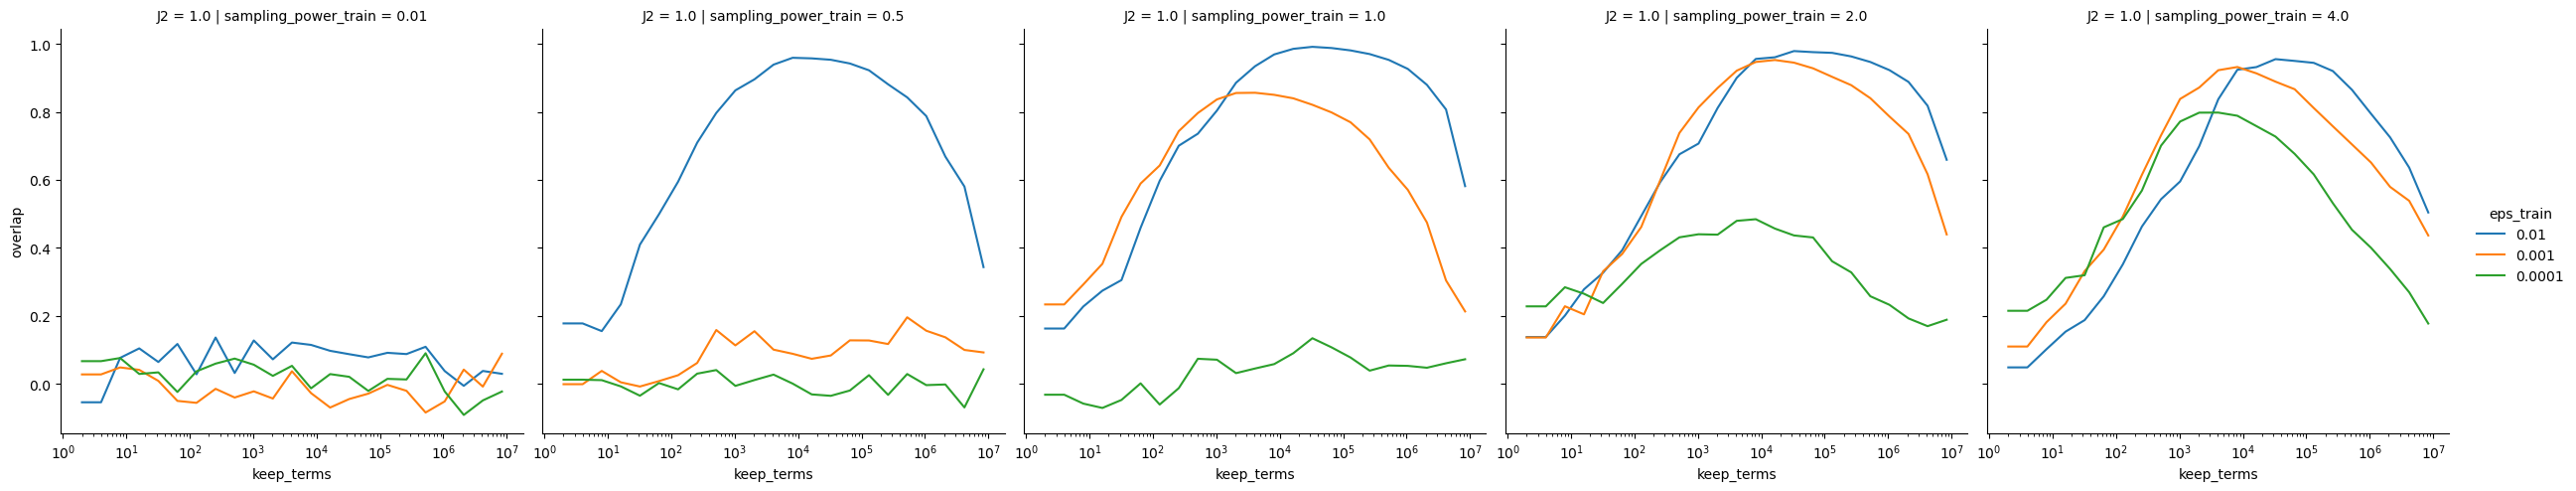

In [40]:
sns.relplot(
    df.assign(log2_keep_terms=np.log2(df["keep_terms"]).astype(int))
    .query(
        'lattice == "kagome2x4" and J2 == 1'
    ).pipe(column_to(str, "eps_train")),
    x="keep_terms",
    y="overlap",
    row="J2",
    col="sampling_power_train",
    hue='eps_train',
    kind="line",
).set(xscale="log")
plt.savefig("fig/fourier_supervised_cleanroom-overlap-v-keep_terms.pdf")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


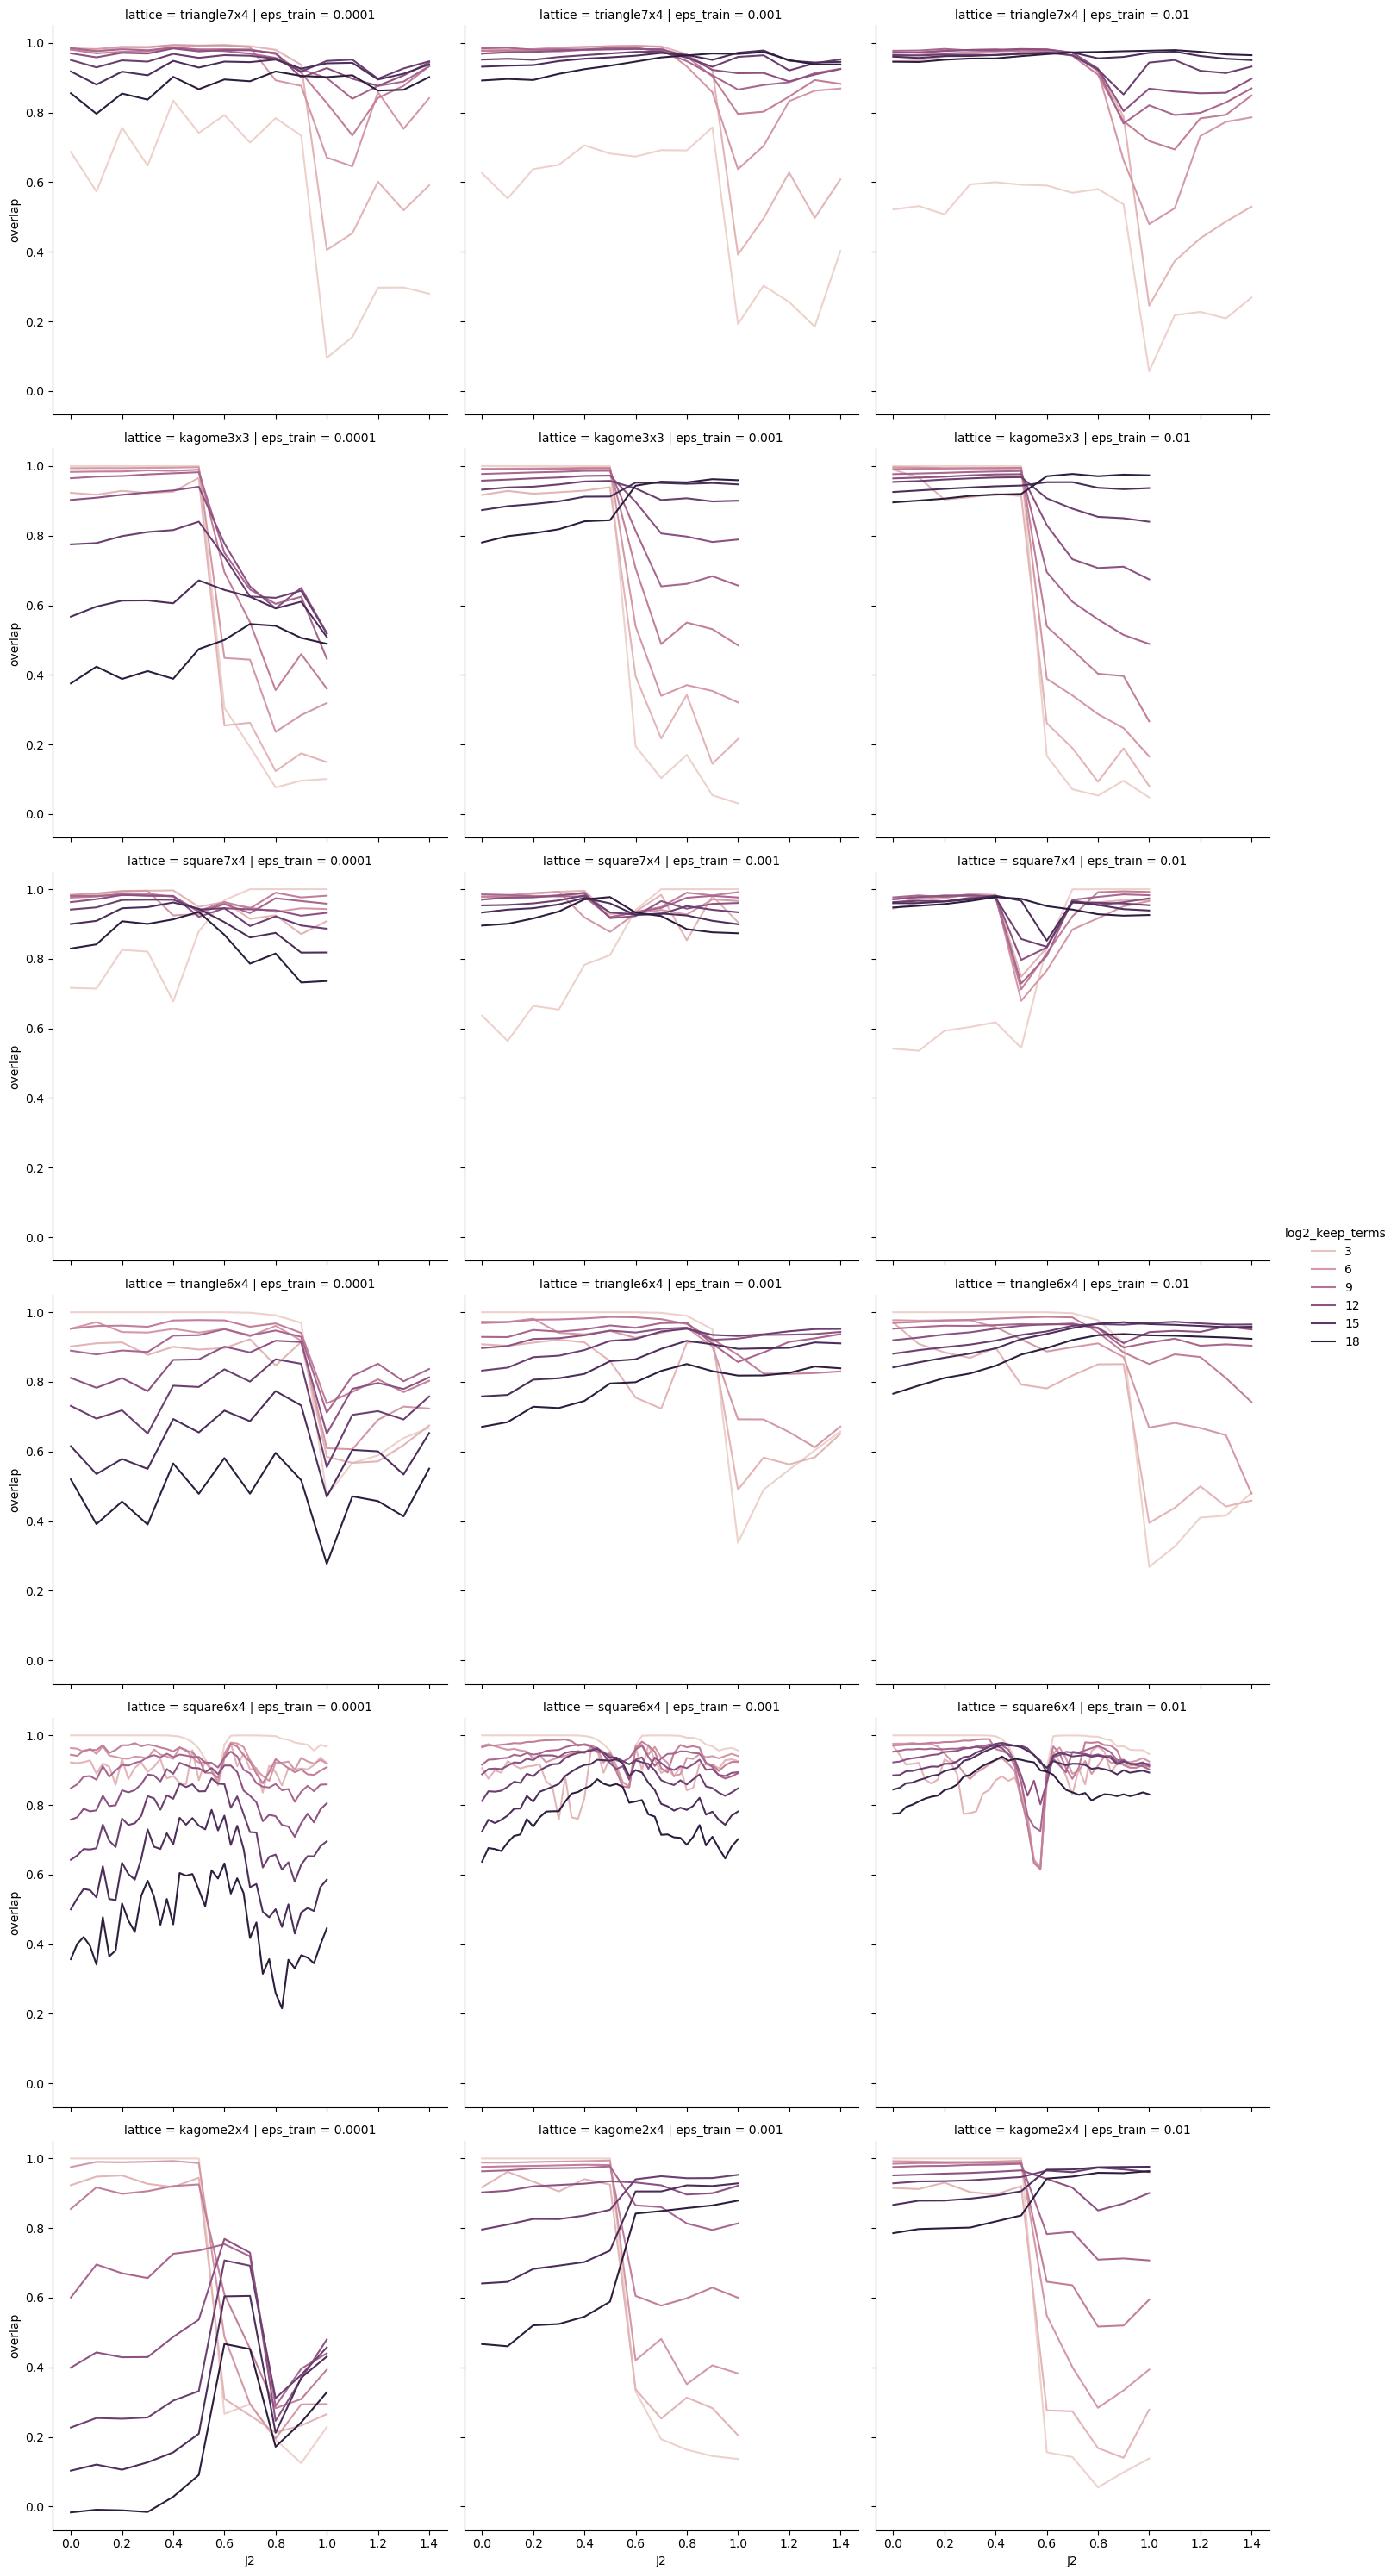

In [8]:
sns.relplot(
    df.assign(log2_keep_terms=np.log2(df["keep_terms"]).astype(int)).query(
        "log2_keep_terms < 20 and log2_keep_terms % 2 == 0 and sampling_power_train == 2"
    ),
    x="J2",
    y="overlap",
    col="eps_train",
    row="lattice",
    hue="log2_keep_terms",
    kind="line",
)

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


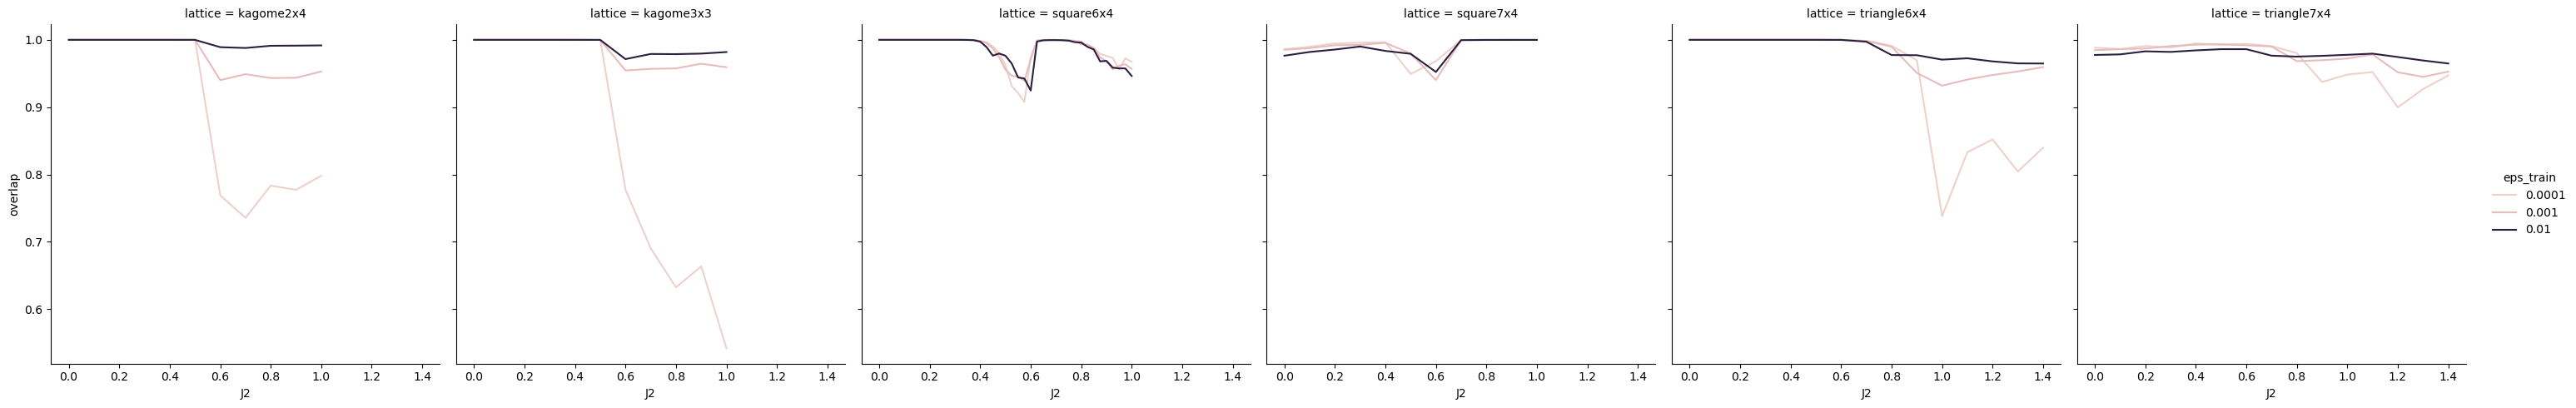

In [6]:
sns.relplot(
    df.groupby(["lattice", "eps_train", "J2"])["overlap"].max().reset_index(),
    x="J2",
    y="overlap",
    hue="eps_train",
    col="lattice",
    kind="line",
)

In [47]:
df.groupby(["lattice", "eps_train", "J2"])["accuracy"].max().reset_index().query(
    'J2 == 1 and lattice.str.startswith("kagome")'
).set_index(["lattice", "eps_train"])['accuracy'].unstack()

eps_train,0.0001,0.0010,0.0100
lattice,,,
kagome2x4,0.51756,0.58534,0.62004
kagome3x3,0.51688,0.61154,0.65642


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


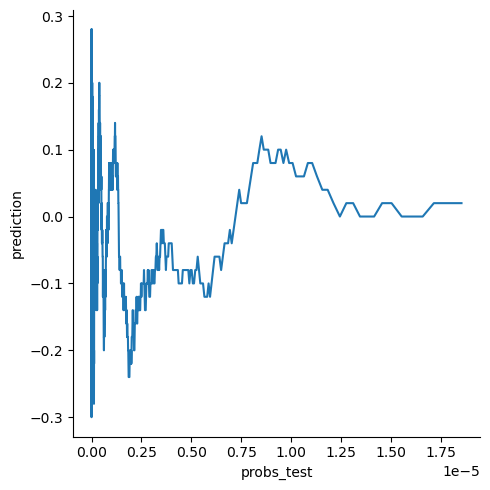

In [16]:
df = pd.DataFrame(
    dict(
        probs_test=probs_test,
        prediction=prediction,
        ground_truth=ground_truth,
        correct=(prediction == ground_truth),
    )
).sort_values('probs_test', ascending=False).reset_index(drop=True)

sns.relplot(df.rolling(window=100).mean(), x='probs_test', y='prediction', kind='line')

In [129]:
eps_train = 0.01

n_samples = int(system.basis.number_states * eps_train)
n_samples_test = 10000
train_set_repr = np.random.choice(
    (system.basis.states), size=n_samples, replace=False, p=probs
)

In [130]:
np.sort(train_set_repr)

array([   61047,    61341,    95975, ..., 16681282, 16681352, 16683270],
      dtype=uint64)

In [131]:
states = system.canonical_basis.states
train_states = states[np.isin(system.basis.state_info(states)[0], train_set_repr)]

In [132]:
assert set(system.basis.state_info(train_states)[0]) == set(train_set_repr)

In [133]:
test_states = np.random.choice(
    states[~np.isin(states, train_states)], size=n_samples_test, replace=True
)
# true_test_signs = np.sign(system.get_ground_state_coeffs(test_states))
true_test_amplitudes = np.abs(system.get_ground_state_coeffs(test_states))

In [157]:
amplitude_binarizer(system, bit=1)(train_states).mean()

-0.31511408601752894

In [158]:
assert (
    set(system.basis.state_info(test_states)[0]) & set(system.basis.state_info(train_states)[0])
    == set()
)

In [159]:
def get_signal(system, transformation_function, states):
    signal = np.zeros(2 ** system.number_spins, dtype=np.float64)
    signal[states] = transformation_function(states)
    return signal

In [160]:
def sign_signal(system):
    def wrapper(states):
        return np.sign(system.get_ground_state_coeffs(states))
    return wrapper

In [177]:
keep_terms = 10000
signal_function = amplitude_binarizer(system, bit=1)
# signal_function = sign_signal(system)
# signal = system.get_ground_state_in_full_basis().astype(np.float64)
# signal_train = np.zeros_like(signal)
signal_train = get_signal(system, signal_function, train_states)
true_test_signs = signal_function(test_states)

signal_train = torch.from_numpy(signal_train)
signal_train = hadamard_transform_pytorch_inplace(signal_train).numpy()
signal_train = keep_largest_n_inplace(signal_train, keep_terms)
signal_train = hadamard_transform_pytorch_inplace(torch.from_numpy(signal_train)).numpy()

In [178]:
predicted_test_signs = np.sign(signal_train[test_states])
sign_overlap = (true_test_signs * predicted_test_signs * true_test_amplitudes ** 2).sum() / np.sum(
    true_test_amplitudes ** 2
)

In [179]:
sign_overlap

0.4113196242703932

In [180]:
(true_test_signs == predicted_test_signs).mean()

0.5568